In [ ]:
# 1. Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# 2. Install the split-folders library to easily split the dataset
!pip install split-folders

import zipfile
import os
import splitfolders

# 3. Unzip the dataset
# --- Make sure this path is correct in your Drive ---
zip_path = "/content/drive/MyDrive/PlantVillage.zip"
extract_path = "/content/PlantVillage_extracted"

print("Starting extraction...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction complete!")

# 4. Split the dataset into train, validation, and test sets
input_folder = os.path.join(extract_path, "PlantVillage") # Path to the folder with class subdirectories
output_folder = "/content/dataset_split"

# The ratio is 70% for training, 15% for validation, and 15% for testing
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.7, 0.15, 0.15))
print("Dataset successfully split into train, val, and test folders.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting extraction...
Extraction complete!


Copying files: 16913 files [00:04, 3745.57 files/s]

Dataset successfully split into train, val, and test folders.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import os

# --- Hyperparameters and Device Configuration ---
BATCH_SIZE = 32
NUM_EPOCHS = 15 # You trained for 30, but 15 is often enough for great results
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Image Transformations ---
# Augmentation for the training set to make the model more robust
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # EfficientNetB0 standard size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Simpler transformation for validation and testing
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Create Datasets and DataLoaders ---
data_dir = "/content/dataset_split"

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Get Class Information ---
NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f"Found {NUM_CLASSES} classes.")
print("Classes:", CLASS_NAMES)

Using device: cuda
Found 11 classes.
Classes: ['Background', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
# 1. Load the pre-trained EfficientNet-B0 model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Replace the final layer for our specific number of classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)

# 3. Move the model to the configured device (GPU or CPU)
model = model.to(DEVICE)

# 4. Define Loss, Optimizer, and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
def train_one_epoch(loader, model, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(loader, model, criterion, device):
    model.eval() # Set model to evaluation mode
    y_true, y_pred = [], []
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_loss = running_loss / total
    val_acc = correct / total
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0)

    return val_loss, val_acc, report

In [ ]:
best_val_acc = 0.0
model_save_path = "/content/drive/MyDrive/efficientnet_b0_tomato_best.pth" # Model will be saved here

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)
    val_loss, val_acc, report = evaluate(val_loader, model, criterion, DEVICE)
    scheduler.step()

    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save the model if it's the best one so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"✅ New best model saved with accuracy: {best_val_acc:.4f}")

print("\nTraining Finished!")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best model saved to: {model_save_path}")


--- Epoch 1/15 ---
Train Loss: 0.4647 | Train Acc: 0.8546
Val   Loss: 0.1806 | Val Acc: 0.9364
✅ New best model saved with accuracy: 0.9364

--- Epoch 2/15 ---
Train Loss: 0.2323 | Train Acc: 0.9227
Val   Loss: 0.0996 | Val Acc: 0.9633
✅ New best model saved with accuracy: 0.9633

--- Epoch 3/15 ---
Train Loss: 0.1928 | Train Acc: 0.9355
Val   Loss: 0.0900 | Val Acc: 0.9727
✅ New best model saved with accuracy: 0.9727

--- Epoch 4/15 ---
Train Loss: 0.1686 | Train Acc: 0.9427
Val   Loss: 0.1414 | Val Acc: 0.9562

--- Epoch 5/15 ---
Train Loss: 0.1334 | Train Acc: 0.9566
Val   Loss: 0.0472 | Val Acc: 0.9870
✅ New best model saved with accuracy: 0.9870

--- Epoch 6/15 ---
Train Loss: 0.1223 | Train Acc: 0.9595
Val   Loss: 0.0456 | Val Acc: 0.9866

--- Epoch 7/15 ---
Train Loss: 0.1128 | Train Acc: 0.9632
Val   Loss: 0.0277 | Val Acc: 0.9901
✅ New best model saved with accuracy: 0.9901

--- Epoch 8/15 ---
Train Loss: 0.0810 | Train Acc: 0.9735
Val   Loss: 0.0332 | Val Acc: 0.9893

--- Ep

In [ ]:
# Load the best performing model weights
model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))

print("\n--- Evaluating on Test Set ---")
test_loss, test_acc, test_report = evaluate(test_loader, model, criterion, DEVICE)

print(f"Test Accuracy: {test_acc:.4f}")
print("Classification Report:")
print(test_report)


--- Evaluating on Test Set ---
Test Accuracy: 0.9973
Classification Report:
                                             precision    recall  f1-score   support

                                 Background     1.0000    1.0000    1.0000       136
                      Tomato_Bacterial_spot     0.9907    1.0000    0.9953       320
                        Tomato_Early_blight     0.9804    1.0000    0.9901       150
                         Tomato_Late_blight     1.0000    0.9965    0.9983       287
                           Tomato_Leaf_Mold     1.0000    1.0000    1.0000       144
                  Tomato_Septoria_leaf_spot     1.0000    1.0000    1.0000       267
Tomato_Spider_mites_Two_spotted_spider_mite     0.9960    1.0000    0.9980       252
                        Tomato__Target_Spot     1.0000    0.9858    0.9928       211
      Tomato__Tomato_YellowLeaf__Curl_Virus     1.0000    0.9938    0.9969       482
                Tomato__Tomato_mosaic_virus     1.0000    1.0000    1.00

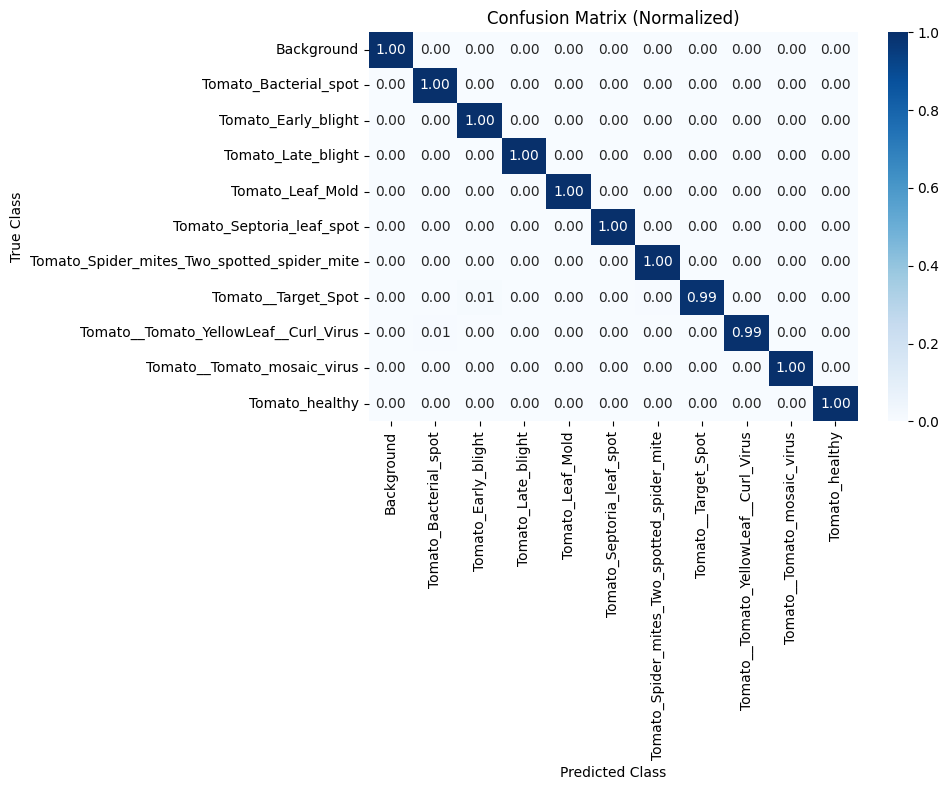

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get true and predicted labels from test set
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


In [ ]:
train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)
val_loss, val_acc, report = evaluate(val_loader, model, criterion, DEVICE)
scheduler.step()

train_losses.append(train_loss)
val_losses.append(val_loss)
train_accuracies.append(train_acc)
val_accuracies.append(val_acc)


In [ ]:
print("NUM_EPOCHS:", NUM_EPOCHS)
print("len(train_losses):", len(train_losses))
print("len(val_losses):", len(val_losses))
print("len(train_accuracies):", len(train_accuracies))
print("len(val_accuracies):", len(val_accuracies))


NUM_EPOCHS: 15
len(train_losses): 1
len(val_losses): 1
len(train_accuracies): 1
len(val_accuracies): 1


In [ ]:
# make sure lists are defined once BEFORE the loop
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = 0.0
model_save_path = "/content/drive/MyDrive/efficientnet_b0_tomato_best.pth"

for epoch in range(NUM_EPOCHS):
    # training step
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)
    # validation step
    val_loss, val_acc, report = evaluate(val_loader, model, criterion, DEVICE)
    # scheduler step (usually after validation)
    scheduler.step()

    # append values each epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"✅ New best model saved at epoch {epoch+1} with val_acc={best_val_acc:.4f}")

    # print progress
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")


✅ New best model saved at epoch 1 with val_acc=0.9961
Epoch 1/15 | Train Loss: 0.0497 Train Acc: 0.9828 | Val Loss: 0.0151 Val Acc: 0.9961
Epoch 2/15 | Train Loss: 0.0414 Train Acc: 0.9854 | Val Loss: 0.0187 Val Acc: 0.9957
Epoch 3/15 | Train Loss: 0.0387 Train Acc: 0.9877 | Val Loss: 0.0169 Val Acc: 0.9949
Epoch 4/15 | Train Loss: 0.0392 Train Acc: 0.9859 | Val Loss: 0.0190 Val Acc: 0.9957
Epoch 5/15 | Train Loss: 0.0556 Train Acc: 0.9822 | Val Loss: 0.0200 Val Acc: 0.9941
✅ New best model saved at epoch 6 with val_acc=0.9964
Epoch 6/15 | Train Loss: 0.0609 Train Acc: 0.9780 | Val Loss: 0.0132 Val Acc: 0.9964
Epoch 7/15 | Train Loss: 0.0876 Train Acc: 0.9702 | Val Loss: 0.0409 Val Acc: 0.9889
Epoch 8/15 | Train Loss: 0.0929 Train Acc: 0.9700 | Val Loss: 0.0334 Val Acc: 0.9885
Epoch 9/15 | Train Loss: 0.0938 Train Acc: 0.9685 | Val Loss: 0.0390 Val Acc: 0.9866
Epoch 10/15 | Train Loss: 0.0984 Train Acc: 0.9689 | Val Loss: 0.0378 Val Acc: 0.9885
Epoch 11/15 | Train Loss: 0.1199 Train Ac

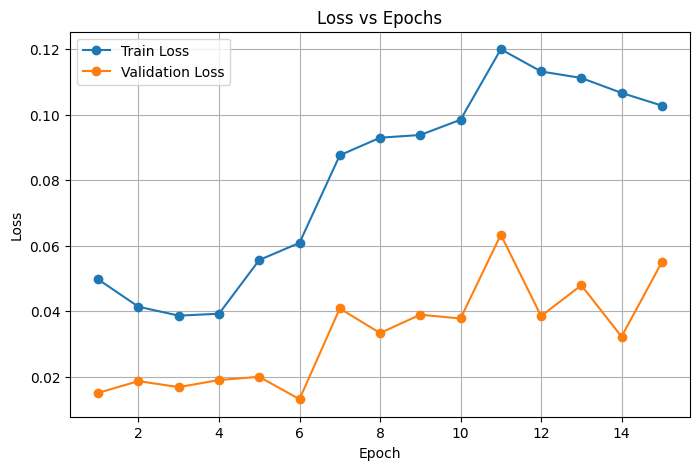

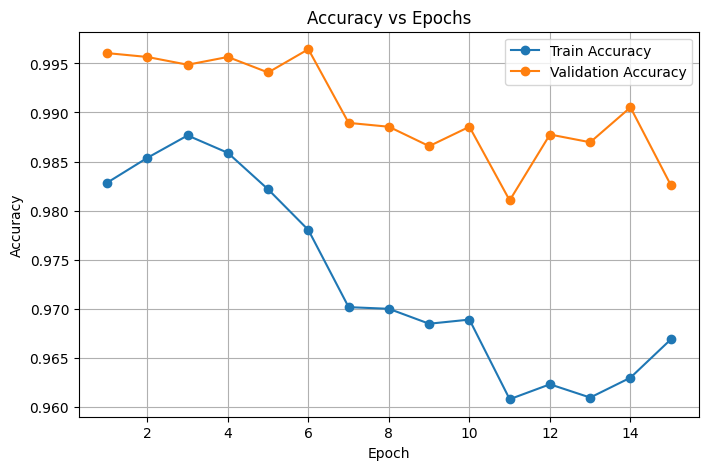

In [ ]:
import matplotlib.pyplot as plt

# find how many points we actually have
epochs_recorded = len(train_losses)
if epochs_recorded == 0:
    raise RuntimeError("No training history recorded. Make sure train_losses is being appended each epoch.")

x = list(range(1, epochs_recorded + 1))

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(x, train_losses[:epochs_recorded], label='Train Loss', marker='o')
plt.plot(x, val_losses[:epochs_recorded], label='Validation Loss', marker='o')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(x, train_accuracies[:epochs_recorded], label='Train Accuracy', marker='o')
plt.plot(x, val_accuracies[:epochs_recorded], label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
